In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn.objects as so
import fig07
from IPython.display import clear_output
from joblib import Parallel, delayed

from drift_diffusion.sim import sample_from_pdf

# notebook defaults
plt.rcParams.update({"font.size": 14, "font.family": "Helvetica", "savefig.transparent": True})
so.Plot.config.theme.update(plt.rcParams)

In [2]:
# true parameters and sample sizes to test
params = {"a": 0.63, "t0": 0.435, "v": 2.23, "z": 0.008}
sample_sizes, n_repeats = [500, 1000, 5000, 10000], 100

In [3]:
# !! x min runtime if refit !!
REFIT = False  # True to refit model comparison, False to load precomputed results


@delayed
def run_simulation(rep, n):
    X = pd.DataFrame({"intercept": np.ones(n)})
    y = sample_from_pdf(**params, n_samples=n, random_state=rep + n)
    y_df = pd.DataFrame({"rt": np.abs(y), "response": np.sign(y)})
    return fig07.fit_mle(X, y), fig07.fit_mcmc(y_df)


# compare both models across sample sizes using normalized absolute error
df = []
if REFIT:
    for n in sample_sizes:
        with Parallel(n_jobs=-4) as parallel:
            results = parallel(run_simulation(rep, n) for rep in range(n_repeats))
            clear_output()
        mle, mcmc = zip(*results)

        for method, values in (("mle", mle), ("mcmc", mcmc)):
            runtime, params_, uncs_ = map(np.stack, zip(*values))
            df.extend(fig07.summarize_method(n, method, runtime, params, params_, uncs_))

    df = pd.DataFrame.from_records(df)

else:
    df = pd.read_csv("./results/tab-mle-vs-mcmc.csv", index_col=0)

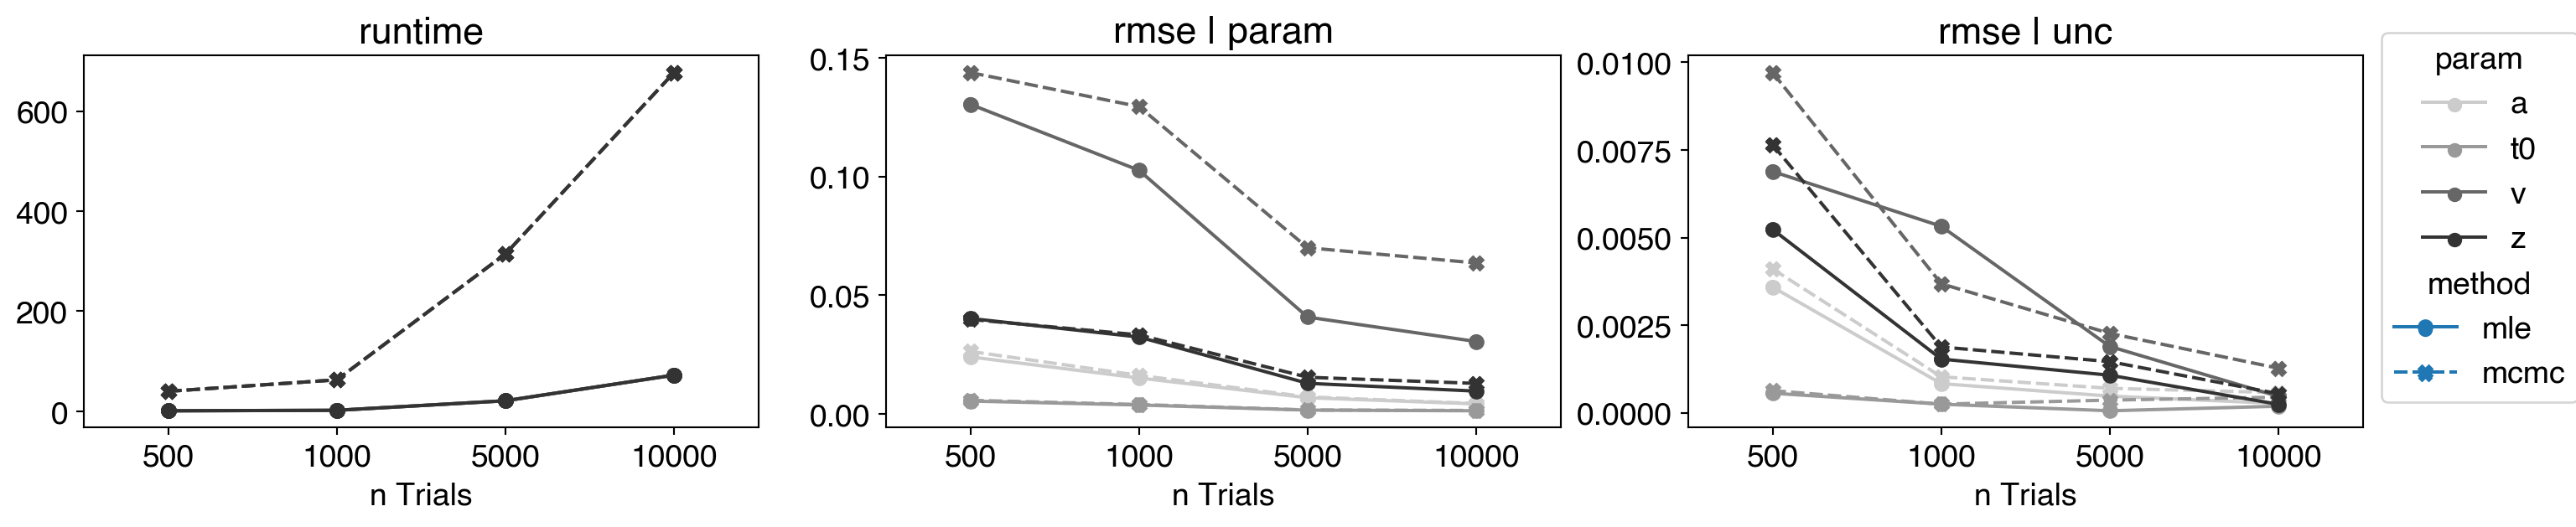

In [4]:
df_plot = (
    df.melt(id_vars=["n", "method", "estimate", "param"], value_vars=["runtime", "rmse"])
    .assign(panel=lambda x: np.where(x["variable"].eq("runtime"), "runtime", "rmse | " + x["estimate"]))
    .query("panel in ['runtime', 'rmse | param', 'rmse | unc']")
)

(
    so.Plot(df_plot, x="n", y="value", color="param", marker="method", linestyle="method")
    .facet(col="panel")
    .layout(size=(15, 3.5))
    .add(so.Dot())
    .add(so.Line())
    .scale(color="binary", x=so.Nominal(order=sample_sizes))
    .share(y=False)
    .label(x="n Trials", y="")
)